# Train Static Classifier (ASL Alphabet A–Z + del/nothing/space)

Trains a dense neural network on `model/static_classifier/static_data.csv`
and exports to TFLite for use in `app_taipy.py`.

**Dataset:** The `asl-alphabet` folder is already in the repo root.

**Step 1:** Run the ingestion cell below to extract MediaPipe landmarks from the images.
**Step 2:** Run the training cells to train and export the model.

All cells should be run from the `asl-classifier/` directory.

## 0. Extract Landmarks from Images

In [2]:
# Run from holistic-lstm-asl/ directory.
# Walks asl-alphabet/asl_alphabet_train/asl_alphabet_train/ (one subfolder per class),
# runs MediaPipe Hands on each image, and writes landmark CSVs.
# Takes ~10-20 minutes depending on hardware.

import subprocess, sys

result = subprocess.run(
    [
        sys.executable, '-m', 'ingest.from_images',
        '--source',     '../asl-alphabet/asl_alphabet_train/asl_alphabet_train',
        '--out_csv',    'model/static_classifier/static_data.csv',
        '--out_labels', 'model/static_classifier/static_labels.csv',
        '--skip',       'nothing',   # optional: remove 'nothing' class if unwanted
    ],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Found 28 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']

✅ Static dataset extraction complete.
   Rows written : 63,579
   Skipped      : 20,421  (no hand detected)
   Output CSV   : model/static_classifier/static_data.csv
   Labels       : model/static_classifier/static_labels.csv



## 1. Configuration

In [3]:
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [4]:
DATASET_PATH   = 'model/static_classifier/static_data.csv'
LABELS_PATH    = 'model/static_classifier/static_labels.csv'
MODEL_SAVE     = 'model/static_classifier/static_classifier.hdf5'
TFLITE_SAVE    = 'model/static_classifier/static_classifier.tflite'

INPUT_DIM        = 42      # 21 landmarks × (x, y)
EPOCHS           = 100
BATCH_SIZE       = 128
VALIDATION_SPLIT = 0.15

# Load class names
with open(LABELS_PATH, encoding='utf-8-sig') as f:
    class_names = [l.strip() for l in f if l.strip()]
NUM_CLASSES = len(class_names)
print(f'{NUM_CLASSES} classes: {class_names}')

28 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 2. Load Dataset

In [6]:
X, y = [], []
with open(DATASET_PATH, encoding='utf-8') as f:
    for row in csv.reader(f):
        if not row:
            continue
        label = int(row[0])
        features = [float(v) for v in row[1:]]
        if len(features) == INPUT_DIM:
            y.append(label)
            X.append(features)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f'Samples : {len(X):,}')
print(f'Shape   : {X.shape}')

# Class distribution
unique, counts = np.unique(y, return_counts=True)
for idx, cnt in zip(unique, counts):
    name = class_names[idx] if idx < NUM_CLASSES else str(idx)
    print(f'  [{idx:3d}] {name:<12}  {cnt:5,} samples')

Samples : 63,579
Shape   : (63579, 42)
  [  0] A             2,182 samples
  [  1] B             2,202 samples
  [  2] C             1,962 samples
  [  3] D             2,457 samples
  [  4] E             2,307 samples
  [  5] F             2,864 samples
  [  6] G             2,428 samples
  [  7] H             2,373 samples
  [  8] I             2,379 samples
  [  9] J             2,571 samples
  [ 10] K             2,699 samples
  [ 11] L             2,521 samples
  [ 12] M             1,603 samples
  [ 13] N             1,275 samples
  [ 14] O             2,258 samples
  [ 15] P             2,040 samples
  [ 16] Q             2,118 samples
  [ 17] R             2,545 samples
  [ 18] S             2,555 samples
  [ 19] T             2,354 samples
  [ 20] U             2,509 samples
  [ 21] V             2,548 samples
  [ 22] W             2,453 samples
  [ 23] X             2,156 samples
  [ 24] Y             2,580 samples
  [ 25] Z             2,343 samples
  [ 26] del           1,7

## 3. Train / Validation Split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED,
    stratify=y,
)
print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')

Train : 54,042
Val   : 9,537


## 4. Build Model

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(128, activation='relu', input_shape=(INPUT_DIM,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax'),
], name='static_asl_classifier')

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

c:\Users\themi\anaconda3\envs\dawn\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "static_asl_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,532 (68.48 KB)

 Trainable params: 17,148 (66.98 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Train

In [9]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

val_acc = max(history.history['val_accuracy']) * 100
print(f'\n✅ Best validation accuracy: {val_acc:.2f}%')

Epoch 1/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7874 - loss: 0.7972 - val_accuracy: 0.9486 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 2/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9383 - loss: 0.2259 - val_accuracy: 0.9680 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 3/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9524 - loss: 0.1733 - val_accuracy: 0.9702 - val_loss: 0.1135 - learning_rate: 0.0010
Epoch 4/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9586 - loss: 0.1476 - val_accuracy: 0.9737 - val_loss: 0.0998 - learning_rate: 0.0010
Epoch 5/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9635 - loss: 0.1321 - val_accuracy: 0.9758 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 6/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9653 - loss: 0.1233 - val_accuracy: 0.9777 - val_loss: 0.0812 - learning_rate: 0.0010
Epoch 7/100
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.

## 6. Evaluate

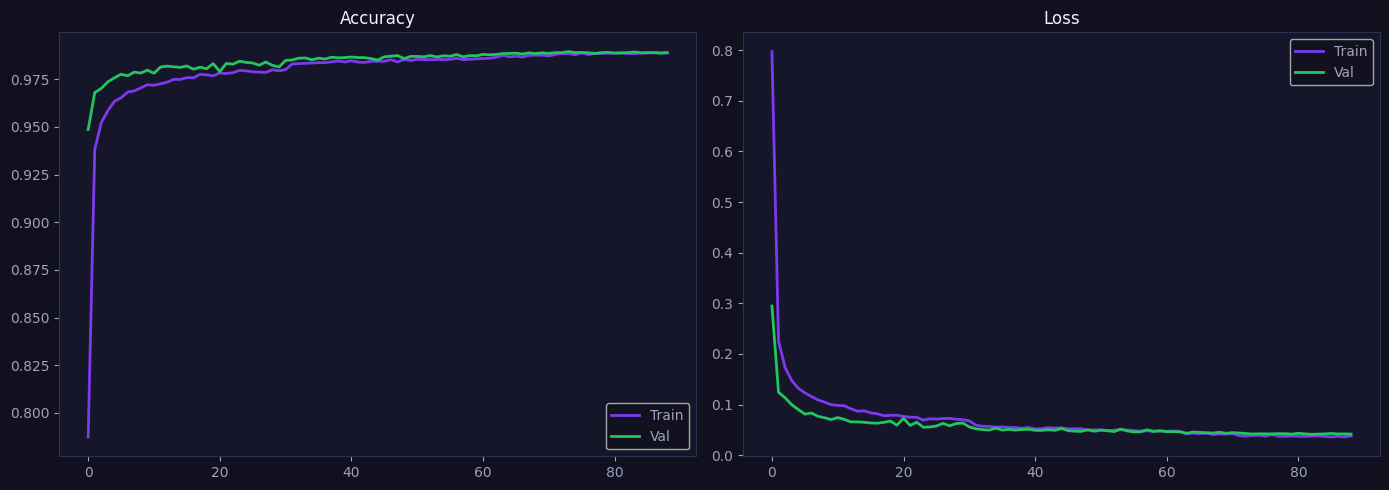

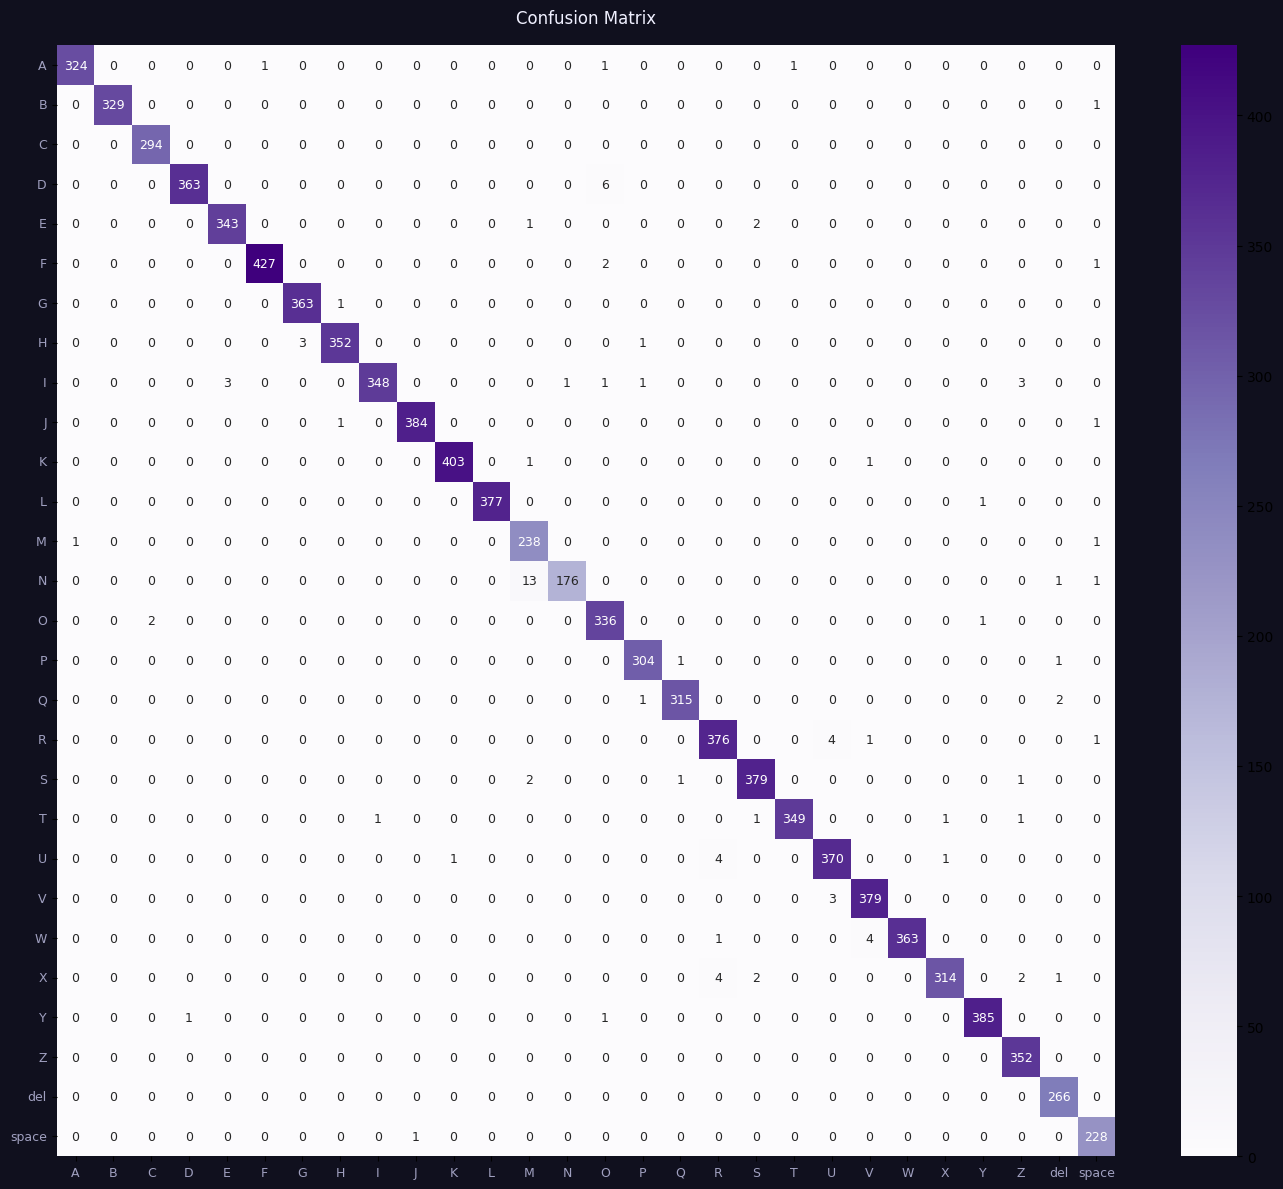

              precision    recall  f1-score   support

           A       1.00      0.99      0.99       327
           B       1.00      1.00      1.00       330
           C       0.99      1.00      1.00       294
           D       1.00      0.98      0.99       369
           E       0.99      0.99      0.99       346
           F       1.00      0.99      1.00       430
           G       0.99      1.00      0.99       364
           H       0.99      0.99      0.99       356
           I       1.00      0.97      0.99       357
           J       1.00      0.99      1.00       386
           K       1.00      1.00      1.00       405
           L       1.00      1.00      1.00       378
           M       0.93      0.99      0.96       240
           N       0.99      0.92      0.96       191
           O       0.97      0.99      0.98       339
           P       0.99      0.99      0.99       306
           Q       0.99      0.99      0.99       318
           R       0.98    

In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#10101e')

for ax in axes:
    ax.set_facecolor('#16162a')
    ax.tick_params(colors='#a0a0c0')
    ax.spines[:].set_color('#303050')

axes[0].plot(history.history['accuracy'],      color='#7c3aed', linewidth=2, label='Train')
axes[0].plot(history.history['val_accuracy'],  color='#22c55e', linewidth=2, label='Val')
axes[0].set_title('Accuracy', color='#f0f0ff')
axes[0].legend(facecolor='#10101e', labelcolor='#a0a0c0')

axes[1].plot(history.history['loss'],          color='#7c3aed', linewidth=2, label='Train')
axes[1].plot(history.history['val_loss'],      color='#22c55e', linewidth=2, label='Val')
axes[1].set_title('Loss', color='#f0f0ff')
axes[1].legend(facecolor='#10101e', labelcolor='#a0a0c0')

plt.tight_layout()
plt.savefig('model/static_classifier/training_curves.png', dpi=120)
plt.show()

# Confusion matrix
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(14, 12), facecolor='#10101e')
ax = plt.gca()
ax.set_facecolor('#16162a')
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 9})
plt.title('Confusion Matrix', color='#f0f0ff', pad=16)
plt.xticks(color='#a0a0c0', fontsize=9)
plt.yticks(color='#a0a0c0', fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('model/static_classifier/confusion_matrix.png', dpi=120)
plt.show()

print(classification_report(y_val, y_pred, target_names=class_names))

## 7. Save & Export to TFLite

In [11]:
# Save Keras model
model.save(MODEL_SAVE)
print(f'Keras model saved → {MODEL_SAVE}')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_SAVE, 'wb') as f:
    f.write(tflite_model)

print(f'TFLite model saved → {TFLITE_SAVE}  ({len(tflite_model)/1024:.1f} KB)')

# Verify TFLite predictions match Keras
interp = tf.lite.Interpreter(model_path=TFLITE_SAVE)
interp.allocate_tensors()
in_idx  = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

mismatches = 0
for i in range(min(10, len(X_val))):
    interp.set_tensor(in_idx, X_val[i:i+1])
    interp.invoke()
    tfl_pred = np.argmax(interp.get_tensor(out_idx))
    ker_pred = np.argmax(model.predict(X_val[i:i+1], verbose=0))
    if tfl_pred != ker_pred:
        mismatches += 1
        print(f'  [MISMATCH] sample {i}: Keras={ker_pred}, TFLite={tfl_pred}')

print(f'TFLite verification: {10 - mismatches}/10 predictions match Keras ✅')

Keras model saved → model/static_classifier/static_classifier.hdf5
INFO:tensorflow:Assets written to: C:\Users\themi\AppData\Local\Temp\tmpk1s1i21t\assets


INFO:tensorflow:Assets written to: C:\Users\themi\AppData\Local\Temp\tmpk1s1i21t\assets


Saved artifact at 'C:\Users\themi\AppData\Local\Temp\tmpk1s1i21t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  2339097068464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097073392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097074272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097077440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097075152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097076208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097074800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097078320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097075328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097081136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339097076912

c:\Users\themi\anaconda3\envs\dawn\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite verification: 10/10 predictions match Keras ✅
